# **Initialization**

In [ ]:
import os
# Disable cuDNN autotuning to ensure deterministic and consistent VRAM allocation
# during benchmarking. Without this, cuDNN may select different algorithms across
# runs, leading to non-reproducible memory measurements.
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

## Environment Setup & Dependencies

In [ ]:
# Install required packages for Transformer models
!pip install transformers==4.41.2 -q
!pip install tf-keras -q

import os
import random
import tensorflow as tf
import numpy as np

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print("[SUCCESS] Random seeds locked for reproducibility!")

set_seeds(42)

[SUCCESS] Random seeds locked for reproducibility!


## Helper Function to calculate VRAM usage

In [ ]:
import tensorflow as tf

# ==========================================
# 1. VRAM PROFILING HELPERS
# ==========================================

def get_peak_vram_mb():
    """Get the Peak VRAM allocated by TensorFlow empirically."""
    try:
        mem_info = tf.config.experimental.get_memory_info('GPU:0')
        peak_bytes = mem_info['peak']
        return peak_bytes / (1024 ** 2) # Convert Bytes to MB
    except Exception as e:
        print(f"[WARNING] Failed to get VRAM info: {e}")
        return 0.0

# **Exploration and Data Preparation**

## Download and Load dataset

In [1]:
import pandas as pd
import requests
import io
import os

# github content download link
github_content_url = 'https://raw.githubusercontent.com/fauzanharsya/ID-SMSA-Sentiment-Analysis/refs/heads/main/IDSMSA.csv'
output = 'dataset.csv'

print(f"Downloading from: {github_content_url}")

try:
    response = requests.get(github_content_url, stream=True)
    response.raise_for_status()

    with open(output, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print("Download complete.")

    if os.path.exists(output):
        try:
            df = pd.read_csv(output, sep=',', engine='python', on_bad_lines='skip')
            print("Dataset loaded successfully!")
            display(df.head())
        except Exception as e:
            print(f"Error loading dataset: {e}")
    else:
        print("Failed to download the dataset.")

except requests.exceptions.RequestException as e:
    print(f"Error during download: {e}")

Download complete.
Dataset loaded successfully!


,Tweet Date,Sentence,Quote Count,Reply Count,Retweet Count,Favorite Count,Sentiment,English Translation
0,Thu Feb 29 11:21:27 +0000 2024,"Gk muluk muluk, 100,000 lot saham BBCA aja",0,0,0,0,Positive,"Not too ambitious, just 100,000 lots of BBCA s..."
1,Thu Feb 29 10:11:05 +0000 2024,BCA Expoversary 2024 menawarkan promo suku bun...,0,0,0,0,Neutral,BCA Expoversary 2024 offers special interest r...
2,Thu Feb 29 10:06:04 +0000 2024,[USERNAME] saham bca nya menyusul ya 🙂,0,0,0,0,Positive,[USERNAME] BCA shares will follow 🙂
3,Thu Feb 29 07:42:09 +0000 2024,PT Bank BCA Syariah (BCA Syariah) turut memeri...,0,0,0,0,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...
4,Thu Feb 29 06:06:17 +0000 2024,[USERNAME] Begitu byk saham kamu memilih saham...,0,0,0,1,Positive,[USERNAME] So many stocks you choose those sto...


## Data Exploration

In [ ]:
# Check data types, missing values, and basic statistics of the dataset
display(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Tweet Date           3288 non-null   object
 1   Sentence             3288 non-null   object
 2   Quote Count          3288 non-null   int64 
 3   Reply Count          3288 non-null   int64 
 4   Retweet Count        3288 non-null   int64 
 5   Favorite Count       3288 non-null   int64 
 6   Sentiment            3288 non-null   object
 7   English Translation  3288 non-null   object
dtypes: int64(4), object(4)
memory usage: 205.6+ KB


None

,Tweet Date,Sentence,Quote Count,Reply Count,Retweet Count,Favorite Count,Sentiment,English Translation
count,3288,3288,3288.000000,3288.000000,3288.000000,3288.000000,3288,3288
unique,3263,3254,NaN,NaN,NaN,NaN,3,3251
top,Tue Dec 12 06:08:27 +0000 2023,[HASHTAG] PT Telkom Indonesia Tbk (TLKM) membu...,NaN,NaN,NaN,NaN,Positive,"BBNI shares closed at Rp5,375 per share or up ..."
freq,2,4,NaN,NaN,NaN,NaN,1769,5
mean,NaN,NaN,0.374696,1.113747,1.276460,7.162409,NaN,NaN
std,NaN,NaN,7.214358,8.818134,26.474467,136.684489,NaN,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,0.000000,1.000000,0.000000,1.000000,NaN,NaN


,count
Sentiment,
Positive,1769
Negative,786
Neutral,733


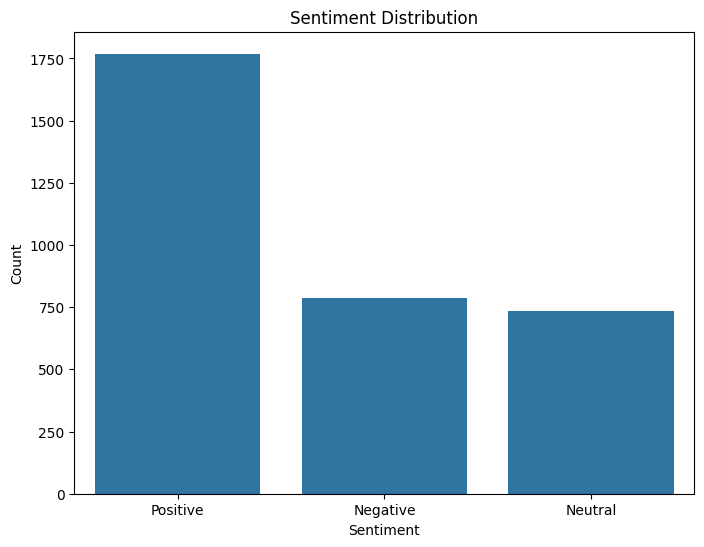

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get value counts for the 'Sentiment' column
sentiment_counts = df['Sentiment'].value_counts()

# Display the value counts
display(sentiment_counts)

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## Preprocessing

In [ ]:
# Drop unnecessary columns
df = df[['Sentence', 'Sentiment', 'English Translation']]

# Display the head of the modified DataFrame
display(df.head())

,Sentence,Sentiment,English Translation
0,"Gk muluk muluk, 100,000 lot saham BBCA aja",Positive,"Not too ambitious, just 100,000 lots of BBCA s..."
1,BCA Expoversary 2024 menawarkan promo suku bun...,Neutral,BCA Expoversary 2024 offers special interest r...
2,[USERNAME] saham bca nya menyusul ya 🙂,Positive,[USERNAME] BCA shares will follow 🙂
3,PT Bank BCA Syariah (BCA Syariah) turut memeri...,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...
4,[USERNAME] Begitu byk saham kamu memilih saham...,Positive,[USERNAME] So many stocks you choose those sto...


In [ ]:
import pandas as pd
import re

# --- 1. Download Normalization Dictionary (Slang Dictionary) ---
slang_url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
try:
    slang_df = pd.read_csv(slang_url)
    slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))
    print("Normalization dictionary loaded successfully!")
except Exception as e:
    print(f"Failed to load dictionary: {e}")
    slang_dict = {}

# --- 1.5. Creating whitelist related to stock domains ---
# This list is adjusted to the 10 Stocks in Paper ID-SMA
# We enter the Ticker AND the common name of the company to be safe.
saham_whitelist = [
    # 1. BBCA (Bank Central Asia)
    'bbca', 'bca',
    # 2. UNVR (Unilever Indonesia)
    'unvr', 'unilever',
    # 3. TPIA (Chandra Asri Petrochemical)
    'tpia', 'chandra', 'asri',
    # 4. TLKM (Telkom Indonesia)
    'tlkm', 'telkom',
    # 5. HMSP (Hanjaya Mandala Sampoerna)
    'hmsp', 'sampoerna',
    # 6. BYAN (Bayan Resources)
    'byan', 'bayan',
    # 7. BMRI (Bank Mandiri)
    'bmri', 'mandiri',
    # 8. BBRI (Bank Rakyat Indonesia)
    'bbri', 'bri',
    # 9. BBNI (Bank Negara Indonesia)
    'bbni', 'bni',
    # 10. ASII (Astra International)
    'asii', 'astra',

    # --- Important Additions Whitelist Based on the ID-SMSA Dataset ---

    # 1. Other Frequently Appearing Stock Codes (Peers/Competitors)
    'goto', 'buka', 'bukalapak',       # Technology Sector (often compared with digital banks/telcos)
    'admr', 'adro', 'adaro',           # Energy Sector (often compared with BYAN)
    'itmg', 'ptba', 'bumi',            # Energy Sector (Peers)
    'antm', 'antam', 'inco', 'mdka',   # Metal Mining Sector (Peers)
    'icbp', 'indf', 'myor', 'sido',    # Consumer Sector (Peers UNVR/HMSP)
    'ggrm', 'wiim',                    # Tobacco Sector (Peers HMSP)
    'btps', 'bris', 'agro', 'arto',    # Digital/Sharia Banks (Peers Big Banks)
    'pgas', 'pegas',                   # Energy/Infrastructure
    'bren', 'cuan', 'brpt',            # Barito Group (often mentioned along with TPIA)

    # 2. Capital Market Terms (Slang/Acronyms)
    'lot',          # Unit of shares (don't normalize to 'lho' or others)
    'cuan',         # Profit (don't normalize to another word)
    'boncos',       # Loss
    'serok',        # Buy at the bottom (or Scoop)
    'nyangkut',     # Floating Loss (or Stuck/Holding at a loss)
    'cl',           # Cut Loss
    'tp',           # Take Profit
    'haka',         # Hajar Kanan (Direct Buy / Hit Right)
    'haki',         # Hajar Kiri (Direct Sell / Hit Left)
    'ara',          # Auto Reject Atas (Upper Auto Rejection)
    'arb',          # Auto Reject Bawah (Lower Auto Rejection)
    'ath',          # All Time High
    'ytd',          # Year to Date
    'pbv', 'per',   # Financial Ratios
    'ihsg',         # Composite Stock Price Index
    'lq45',         # Stock Index
    'idx',          # Stock Exchange
    'sekuritas',    # Brokerage Firm (or Securities)
    'dividen',      # Dividend
    'stockbit',     # Application (often mentioned)
    'bibit',        # Application
    'ajaib',        # Application
    'ipot'          # Application
]

print(f"Removing {len(saham_whitelist)} stock keywords from slang dictionary...")
for word in saham_whitelist:
    if word in slang_dict:
        del slang_dict[word]

# --- 2. Unified Preprocessing Function ---
def preprocess_text(text, normalize_slang=False):
    # A. Case Folding
    text = text.lower()

    # B. Text Cleaning (Regex)
    text = re.sub(r'\[username\]|\[url\]|\[hashtag\]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+', '', text)

    # C. Normalization (Slang replacement) - only for Indonesian
    if normalize_slang:
        words = text.split()
        normalized_words = [slang_dict.get(word, word) for word in words]
        text = ' '.join(normalized_words)

    # D. Whitespace Removal
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# --- 3. Apply to DataFrame ---
print("Performing preprocessing (Cleaning + Normalization with Complete Whitelist)...")
df['cleaned_sentence'] = df['Sentence'].apply(lambda x: preprocess_text(x, normalize_slang=True))
df['cleaned_english'] = df['English Translation'].apply(lambda x: preprocess_text(x, normalize_slang=False))

print("Preprocessing complete.")

# Perform a random sample check to ensure
print("\nSample data check:")
display(df[['Sentence', 'cleaned_sentence']].sample(5))

Normalization dictionary loaded successfully!
Removing 73 stock keywords from slang dictionary...
Performing preprocessing (Cleaning + Normalization with Complete Whitelist)...
Preprocessing complete.

Sample data check:


,Sentence,cleaned_sentence
2212,"[HASHTAG] Wangi Dividen Tercium, Saham BMRI Ce...",wangi dividen tercium saham bmri cetak rekor t...
670,"[USERNAME] Jelek bgt, w kira proto w paling je...",jelek banget gue kira proto gue paling jelek t...
2723,"Trading Jumat (23/02/2024)嶋 噫 BMRI, SMGR, GJ...",trading jumat bmri smgr gjtl tlkm admr bren ih...
2421,"Kini, Sigit memegang 6.305.100 lembar saham BM...",kini sigit memegang lembar saham bmri dengan p...
999,[HASHTAG] Beberapa saham ini tampaknya layak u...,beberapa saham ini tampaknya layak untuk dicer...


## Label Encoding

In [ ]:
# Show sentiment distribution before encoding
print("Sentiment Distribution Before Encoding:")
print(df['Sentiment'].value_counts())
print("-" * 30)

# 1. Create a dictionary to map sentiments to numbers
sentiment_map = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

# 2. Apply the mapping to create a new 'label' column
df['label'] = df['Sentiment'].map(sentiment_map)

# 3. Display the result to ensure everything is correct
# Note the new 'label' column on the far right
print("DataFrame After Label Encoding:")
display(df.head())

# 4. Re-check the distribution in the new 'label' column to ensure no data is lost
print("\nDistribution in the new 'label' column:")
print(df['label'].value_counts())

Sentiment Distribution Before Encoding:
Sentiment
Positive    1769
Negative     786
Neutral      733
Name: count, dtype: int64
------------------------------
DataFrame After Label Encoding:


,Sentence,Sentiment,English Translation,cleaned_sentence,cleaned_english,label
0,"Gk muluk muluk, 100,000 lot saham BBCA aja",Positive,"Not too ambitious, just 100,000 lots of BBCA s...",enggak muluk muluk lot saham bbca saja,not too ambitious just lots of bbca shares,2
1,BCA Expoversary 2024 menawarkan promo suku bun...,Neutral,BCA Expoversary 2024 offers special interest r...,bca expoversary menawarkan promo suku bunga sp...,bca expoversary offers special interest rate p...,1
2,[USERNAME] saham bca nya menyusul ya 🙂,Positive,[USERNAME] BCA shares will follow 🙂,saham bca nya menyusul ya,bca shares will follow,2
3,PT Bank BCA Syariah (BCA Syariah) turut memeri...,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...,pt bank bca syariah bca syariah turut memeriah...,pt bank bca syariah bca syariah also enlivened...,1
4,[USERNAME] Begitu byk saham kamu memilih saham...,Positive,[USERNAME] So many stocks you choose those sto...,begitu banyak saham kamu memilih saham itu kal...,so many stocks you choose those stocks if you ...,2



Distribution in the new 'label' column:
label
2    1769
0     786
1     733
Name: count, dtype: int64


## Data Splitting & Calculate Class Weight

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np

# ==========================================
# 1. DATA SPLITTING (70:10:20)
# ==========================================

# Step 1: Separate 20% for the Test Set
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20, # 20%
    random_state=42,
    stratify=df['label']
)

# Step 2: Separate the remainder (80%) into Train (70%) and Val (10%)
# 0.125 * 0.80 = 0.10 (10% of Total)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    random_state=42,
    stratify=train_val_df['label']
)

# Size Verification
total = len(df)
print(f"Total Data: {total}")
print(f"Train: {len(train_df)} ({len(train_df)/total:.1%})")
print(f"Val  : {len(val_df)} ({len(val_df)/total:.1%})")
print(f"Test : {len(test_df)} ({len(test_df)/total:.1%})")

# ==========================================
# 2. LABEL PREPARATION (y)
# ==========================================
# We need this to calculate weights and for training later
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

# ==========================================
# 3. CALCULATE CLASS WEIGHTS (Imbalance Solution)
# ==========================================
# This will give a greater weight to minority classes (Negative & Neutral)

# Calculate weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format (so Keras/TensorFlow can read it)
class_weight_dict = dict(enumerate(class_weights_array))

print("\n--- Class Weights (Balancing Weights) ---")
print("Mapping:", sentiment_map) # So we know what 0, 1, 2 refer to
print("Weights:", class_weight_dict)
print("Interpretation: Classes with weight > 1.0 are minority (given more attention).")

Total Data: 3288
Train: 2301 (70.0%)
Val  : 329 (10.0%)
Test : 658 (20.0%)

--- Class Weights (Balancing Weights) ---
Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
Weights: {0: np.float64(1.3945454545454545), 1: np.float64(1.4951267056530215), 2: np.float64(0.6195476575121163)}
Interpretation: Classes with weight > 1.0 are minority (given more attention).


# **Experiment and Evaluation Traditional Model**

## Tokenization

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Parameter Configuration ---
vocab_size = 10000  # Take the top 10,000 words
max_length = 100    # Make sentence length 100 words (enough for tweets)
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# ==========================================
# A. INDONESIAN TOKENIZATION
# ==========================================
print("--- Indonesian Tokenization ---")
tokenizer_id = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
# IMPORTANT: Only fit on training data to prevent cheating (data leakage)
tokenizer_id.fit_on_texts(train_df['cleaned_sentence'])

# Convert text into numbers
train_seq_id = tokenizer_id.texts_to_sequences(train_df['cleaned_sentence'])
val_seq_id   = tokenizer_id.texts_to_sequences(val_df['cleaned_sentence'])
test_seq_id  = tokenizer_id.texts_to_sequences(test_df['cleaned_sentence'])

# Padding (make them the same length)
train_pad_id = pad_sequences(train_seq_id, maxlen=max_length, padding=padding_type, truncating=trunc_type)
val_pad_id   = pad_sequences(val_seq_id, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_pad_id  = pad_sequences(test_seq_id, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Vocab Size ID: {len(tokenizer_id.word_index)}")
print(f"Shape Train ID: {train_pad_id.shape}")

# ==========================================
# B. ENGLISH TOKENIZATION
# ==========================================
print("\n--- English Tokenization ---")
tokenizer_en = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer_en.fit_on_texts(train_df['cleaned_english'])

train_seq_en = tokenizer_en.texts_to_sequences(train_df['cleaned_english'])
val_seq_en   = tokenizer_en.texts_to_sequences(val_df['cleaned_english'])
test_seq_en  = tokenizer_en.texts_to_sequences(test_df['cleaned_english'])

train_pad_en = pad_sequences(train_seq_en, maxlen=max_length, padding=padding_type, truncating=trunc_type)
val_pad_en   = pad_sequences(val_seq_en, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_pad_en  = pad_sequences(test_seq_en, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Vocab Size EN: {len(tokenizer_en.word_index)}")
print(f"Shape Train EN: {train_pad_en.shape}")

--- Indonesian Tokenization ---
Vocab Size ID: 4842
Shape Train ID: (2301, 100)

--- English Tokenization ---
Vocab Size EN: 4200
Shape Train EN: (2301, 100)


## Execute Training (Subprocess Isolation - Accurate VRAM)

In [ ]:
# Save preprocessed data to disk as .npy files so that each subprocess
# can load the data independently without sharing GPU memory or session state.
import numpy as np
import json

DATA_DIR = '/content/vram_benchmark_data'
os.makedirs(DATA_DIR, exist_ok=True)

np.save(f'{DATA_DIR}/train_pad_id.npy', train_pad_id)
np.save(f'{DATA_DIR}/val_pad_id.npy', val_pad_id)
np.save(f'{DATA_DIR}/test_pad_id.npy', test_pad_id)
np.save(f'{DATA_DIR}/train_pad_en.npy', train_pad_en)
np.save(f'{DATA_DIR}/val_pad_en.npy', val_pad_en)
np.save(f'{DATA_DIR}/test_pad_en.npy', test_pad_en)
np.save(f'{DATA_DIR}/y_train.npy', y_train)
np.save(f'{DATA_DIR}/y_val.npy', y_val)
np.save(f'{DATA_DIR}/y_test.npy', y_test)

with open(f'{DATA_DIR}/class_weight.json', 'w') as f:
    json.dump({str(k): v for k, v in class_weight_dict.items()}, f)

print(f"[SUCCESS] All data saved to {DATA_DIR}/")

[SUCCESS] All data saved to /content/vram_benchmark_data/


In [ ]:
from sklearn.metrics import classification_report, f1_score

print("[INFO] Model creation and evaluation functions are defined in the subprocess script for isolated VRAM measurement.")
print("[INFO] See: /content/train_single_model.py")

[INFO] Model creation and evaluation functions are defined in the subprocess script for isolated VRAM measurement.
[INFO] See: /content/train_single_model.py


In [ ]:
script_content = r'''
import os
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

import argparse
import json
import sys
import time
import gc
import random
import numpy as np
import tensorflow as tf

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def create_model(model_type, vocab_size, embedding_dim=64, input_length=100):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=input_length))
    if model_type == 'LSTM':
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)))
    elif model_type == 'GRU':
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64)))
    elif model_type == 'CNN':
        model.add(tf.keras.layers.Conv1D(128, 5, activation='relu'))
        model.add(tf.keras.layers.GlobalMaxPooling1D())
    model.add(tf.keras.layers.Dense(64, activation='relu'))
    model.add(tf.keras.layers.Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model_type', required=True)
    parser.add_argument('--lang', required=True)
    parser.add_argument('--data_dir', required=True)
    parser.add_argument('--vocab_size', type=int, default=10000)
    parser.add_argument('--epochs', type=int, default=10)
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--seq_len', type=int, default=100)
    args = parser.parse_args()

    set_seeds(42)

    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    lang_code = {'Indonesian': 'id', 'English': 'en'}[args.lang]

    X_train = np.load(f"{args.data_dir}/train_pad_{lang_code}.npy")
    X_val = np.load(f"{args.data_dir}/val_pad_{lang_code}.npy")
    X_test = np.load(f"{args.data_dir}/test_pad_{lang_code}.npy")
    y_train = np.load(f"{args.data_dir}/y_train.npy")
    y_val = np.load(f"{args.data_dir}/y_val.npy")
    y_test = np.load(f"{args.data_dir}/y_test.npy")

    with open(f"{args.data_dir}/class_weight.json", 'r') as f:
        class_weight_dict = {int(k): v for k, v in json.load(f).items()}

    print(f"[SUBPROCESS] Training {args.model_type} ({args.lang})...", file=sys.stderr)

    warmup_idx = np.random.choice(len(X_train), args.batch_size, replace=False)
    warmup_model = create_model(args.model_type, args.vocab_size)
    warmup_model.fit(X_train[warmup_idx], y_train[warmup_idx], epochs=1, batch_size=args.batch_size, verbose=0)
    del warmup_model
    tf.keras.backend.clear_session()

    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except Exception as e:
        print(f"[WARNING] Failed to reset memory stats: {e}", file=sys.stderr)

    set_seeds(42)
    model = create_model(args.model_type, args.vocab_size)

    start_time = time.time()
    model.fit(
        X_train, y_train,
        epochs=args.epochs, batch_size=args.batch_size,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict, verbose=0
    )
    training_duration = time.time() - start_time

    try:
        mem_info = tf.config.experimental.get_memory_info('GPU:0')
        vram_mb = mem_info['peak'] / (1024 ** 2)
    except Exception as e:
        print(f"[WARNING] Failed to get memory info: {e}", file=sys.stderr)
        vram_mb = 0.0

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = y_pred_probs.argmax(axis=1)
    acc = float(model.evaluate(X_test, y_test, verbose=0)[1])

    from sklearn.metrics import f1_score
    f1_macro = float(f1_score(y_test, y_pred, average='macro'))

    result = {
        'model': f"{args.model_type}({args.lang})",
        'accuracy': acc,
        'macro_f1': f1_macro,
        'training_time': training_duration,
        'vram_mb': round(vram_mb, 2)
    }
    print(json.dumps(result))

if __name__ == '__main__':
    main()
'''

script_path = '/content/train_single_model.py'
with open(script_path, 'w') as f:
    f.write(script_content)

print(f"[SUCCESS] Subprocess script written to {script_path}")

[SUCCESS] Subprocess script written to /content/train_single_model.py


In [ ]:
import subprocess
import json
import pandas as pd

DATA_DIR = '/content/vram_benchmark_data'
SCRIPT_PATH = '/content/train_single_model.py'

models_to_run = ['LSTM', 'GRU', 'CNN']
languages = ['Indonesian', 'English']

history_scores_traditional = {}

for lang in languages:
    for m_name in models_to_run:
        full_name = f"{m_name}({lang})"
        print(f"\n{'='*50}")
        print(f"Launching subprocess: {full_name}")
        print(f"{'='*50}")

        cmd = [
            'python', SCRIPT_PATH,
            '--model_type', m_name,
            '--lang', lang,
            '--data_dir', DATA_DIR,
            '--vocab_size', '10000',
            '--epochs', '10',
            '--batch_size', '32',
            '--seq_len', '100'
        ]

        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=600
        )

        if result.returncode != 0:
            print(f"[ERROR] {full_name} failed!")
            print(f"STDERR: {result.stderr[-1000:]}")
            continue

        try:
            output = json.loads(result.stdout.strip().split('\n')[-1])
            history_scores_traditional[full_name] = {
                'Accuracy': output['accuracy'],
                'Macro F1': output['macro_f1'],
                'Training Time(s)': round(output['training_time'], 2),
                'VRAM Usage(MB)': output['vram_mb']
            }
            print(f"[SUCCESS] {full_name}: VRAM={output['vram_mb']:.2f} MB, F1={output['macro_f1']:.4f}")
        except Exception as e:
            print(f"[ERROR] Failed to parse output for {full_name}: {e}")
            print(f"STDOUT: {result.stdout[-500:]}")

print("\n\n=== TRADITIONAL MODEL EXPERIMENT RESULTS (SUBPROCESS ISOLATION) ===")
df_results_trad = pd.DataFrame(history_scores_traditional).T.sort_values(by='Macro F1', ascending=False)
display(df_results_trad)


Launching subprocess: LSTM(Indonesian)
[SUCCESS] LSTM(Indonesian): VRAM=50.02 MB, F1=0.7145

Launching subprocess: GRU(Indonesian)
[SUCCESS] GRU(Indonesian): VRAM=49.19 MB, F1=0.6952

Launching subprocess: CNN(Indonesian)
[SUCCESS] CNN(Indonesian): VRAM=216.63 MB, F1=0.7368

Launching subprocess: LSTM(English)
[SUCCESS] LSTM(English): VRAM=38.97 MB, F1=0.6895

Launching subprocess: GRU(English)
[SUCCESS] GRU(English): VRAM=49.99 MB, F1=0.6619

Launching subprocess: CNN(English)
[SUCCESS] CNN(English): VRAM=216.63 MB, F1=0.7223


=== TRADITIONAL MODEL EXPERIMENT RESULTS (SUBPROCESS ISOLATION) ===


,Accuracy,Macro F1,Training Time(s),VRAM Usage(MB)
CNN(Indonesian),0.764438,0.736757,7.40,216.63
CNN(English),0.749240,0.722257,8.72,216.63
LSTM(Indonesian),0.744681,0.714544,13.04,50.02
GRU(Indonesian),0.729483,0.695198,13.30,49.19
LSTM(English),0.729483,0.689493,12.67,38.97
GRU(English),0.703647,0.661913,12.40,49.99


# **Experiment and Evaluation Transformer Model**

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AdamWeightDecay
import tensorflow as tf
import numpy as np
import time
import pandas as pd
from sklearn.metrics import classification_report, f1_score

#--- 1. Tokenization Function (REQUIRED) ---
def tokenize_data(texts, tokenizer, max_len=128):
    return tokenizer(
        texts.tolist(), max_length=max_len, truncation=True, padding='max_length', return_tensors='tf'
    )

#--- 2. Transformer Training & Evaluation Function ---
def run_transformer_experiment(model_name, X_train_text, X_val_text, X_test_text, y_train, y_val, y_test, experiment_name, learning_rate, epochs, batch_size, load_from_pt=False):
    print(f"\n=== TRANSFORMER EXPERIMENT: {experiment_name} ===")
    print(f"Settings -> LR: {learning_rate}, Epochs: {epochs}, Batch Size: {batch_size}")

    # Reset Memory before loading model
    tf.keras.backend.clear_session()
    import gc
    gc.collect()

    print("Loading Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    print("Loading Model...")
    try:
        if load_from_pt:
            model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, from_pt=True)
        else:
            model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    except Exception as e:
        print(f"Normal load failed, trying from_pt=True. Error: {e}")
        model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, from_pt=True)

    print("Tokenizing data...")
    train_enc = tokenize_data(X_train_text, tokenizer)
    val_enc = tokenize_data(X_val_text, tokenizer)
    test_enc = tokenize_data(X_test_text, tokenizer)
    train_dataset = dict(train_enc)
    val_dataset = dict(val_enc)
    test_dataset = dict(test_enc)

    optimizer = AdamWeightDecay(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except Exception as e:
        print(f"[WARNING] Failed to reset memory stats: {e}")

    print(f"Starting Fine-Tuning for {epochs} epochs...")
    start_time = time.time()
    model.fit(
        train_dataset, y_train,
        validation_data=(val_dataset, y_val),
        epochs=epochs, batch_size=batch_size,
        class_weight=class_weight_dict, verbose=1
    )
    end_time = time.time()
    training_duration = end_time - start_time

    # Get Peak VRAM
    vram_usage = get_peak_vram_mb()
    print(f"[INFO] Total Training Time: {training_duration:.2f} seconds")
    print(f"[INFO] Estimated Peak VRAM: {vram_usage:.2f} MB")

    print("Evaluating...")
    logits = model.predict(test_dataset).logits
    y_pred = np.argmax(logits, axis=1)
    print(classification_report(y_test, y_pred, target_names=['Negative','Neutral','Positive']))
    acc = np.mean(y_pred == y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")

    return acc, f1_macro, training_duration, round(vram_usage, 2)

history_scores_transformer = {}

#==========================================================
# EXECUTION 1: INDOBERT (Indonesian Language)
#==========================================================
acc_indobert, f1_indobert, time_indobert, vram_indobert = run_transformer_experiment(
    model_name='indobenchmark/indobert-base-p1',
    X_train_text=train_df['cleaned_sentence'], X_val_text=val_df['cleaned_sentence'], X_test_text=test_df['cleaned_sentence'],
    y_train=y_train, y_val=y_val, y_test=y_test,
    experiment_name="IndoBERT (Indonesian)",
    learning_rate=2e-5, epochs=3, batch_size=16, load_from_pt=True
)
history_scores_transformer['IndoBERT (Indonesian)'] = {
    'Accuracy': acc_indobert, 'Macro F1': f1_indobert,
    'Training Time(s)': time_indobert, 'VRAM Usage(MB)': vram_indobert
}

#==========================================================
# EXECUTION 2: BERT BASE (English Language)
#==========================================================
acc_bert, f1_bert, time_bert, vram_bert = run_transformer_experiment(
    model_name='bert-base-uncased',
    X_train_text=train_df['cleaned_english'], X_val_text=val_df['cleaned_english'], X_test_text=test_df['cleaned_english'],
    y_train=y_train, y_val=y_val, y_test=y_test,
    experiment_name="BERT Base (English)",
    learning_rate=3e-5, epochs=3, batch_size=16, load_from_pt=True
)
history_scores_transformer['BERT (English)'] = {
    'Accuracy': acc_bert, 'Macro F1': f1_bert,
    'Training Time(s)': time_bert, 'VRAM Usage(MB)': vram_bert
}

#==========================================================
# EXECUTION 3: XLM-RoBERTa (Multilingual Baseline on Native Text)
#==========================================================
acc_xlm, f1_xlm, time_xlm, vram_xlm = run_transformer_experiment(
    model_name='xlm-roberta-base',
    X_train_text=train_df['cleaned_sentence'],
    X_val_text=val_df['cleaned_sentence'],
    X_test_text=test_df['cleaned_sentence'],
    y_train=y_train, y_val=y_val, y_test=y_test,
    experiment_name="XLM-RoBERTa (Multilingual ID)",
    learning_rate=2e-5, epochs=3, batch_size=32, load_from_pt=True
)

history_scores_transformer['XLM-RoBERTa (Multilingual)'] = {
    'Accuracy': acc_xlm, 'Macro F1': f1_xlm,
    'Training Time(s)': time_xlm, 'VRAM Usage(MB)': vram_xlm
}

#==========================================
# Display Final Results
#==========================================
print("\n\n=== TRANSFORMER RESULTS SUMMARY (Updated VRAM) ===")
df_final_transformer = pd.DataFrame(history_scores_transformer).T.sort_values(by='Macro F1', ascending=False)
display(df_final_transformer)


=== TRANSFORMER EXPERIMENT: IndoBERT (Indonesian) ===
Settings -> LR: 2e-05, Epochs: 3, Batch Size: 16
Loading Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading Model...


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing data...
Starting Fine-Tuning for 3 epochs...
Epoch 1/3
144/144 [==============================] - 92s 482ms/step - loss: 0.7428 - accuracy: 0.6906 - val_loss: 0.5891 - val_accuracy: 0.7690
Epoch 2/3
144/144 [==============================] - 68s 470ms/step - loss: 0.3478 - accuracy: 0.8757 - val_loss: 0.5196 - val_accuracy: 0.7994
Epoch 3/3
144/144 [==============================] - 68s 471ms/step - loss: 0.1447 - accuracy: 0.9535 - val_loss: 0.7246 - val_accuracy: 0.7994
[INFO] Total Training Time: 227.71 seconds
[INFO] Estimated Peak VRAM: 3908.53 MB
Evaluating...
21/21 [==============================] - 10s 303ms/step
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       157
     Neutral       0.74      0.76      0.75       147
    Positive       0.88      0.87      0.87       354

    accuracy                           0.83       658
   macro avg       0.81      0.81      0.81       658
weighted avg       0.83      0.83 

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing data...
Starting Fine-Tuning for 3 epochs...
Epoch 1/3
144/144 [==============================] - 88s 496ms/step - loss: 0.7745 - accuracy: 0.6801 - val_loss: 0.6500 - val_accuracy: 0.7264
Epoch 2/3
144/144 [==============================] - 67s 467ms/step - loss: 0.3932 - accuracy: 0.8518 - val_loss: 0.5451 - val_accuracy: 0.7964
Epoch 3/3
144/144 [==============================] - 67s 464ms/step - loss: 0.1656 - accuracy: 0.9478 - val_loss: 0.7063 - val_accuracy: 0.7964
[INFO] Total Training Time: 221.85 seconds
[INFO] Estimated Peak VRAM: 3763.03 MB
Evaluating...
21/21 [==============================] - 10s 305ms/step
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.79       157
     Neutral       0.68      0.73      0.70       147
    Positive       0.88      0.83      0.85       354

    accuracy                           0.80       658
   macro avg       0.77      0.79      0.78       658
weighted avg       0.81      0.80 

All PyTorch model weights were used when initializing TFXLMRobertaForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFXLMRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing data...
Starting Fine-Tuning for 3 epochs...
Epoch 1/3
72/72 [==============================] - 93s 1s/step - loss: 1.0191 - accuracy: 0.5206 - val_loss: 0.9400 - val_accuracy: 0.5380
Epoch 2/3
72/72 [==============================] - 72s 995ms/step - loss: 0.8835 - accuracy: 0.6071 - val_loss: 0.7174 - val_accuracy: 0.6930
Epoch 3/3
72/72 [==============================] - 71s 986ms/step - loss: 0.6348 - accuracy: 0.7688 - val_loss: 0.5823 - val_accuracy: 0.7842
[INFO] Total Training Time: 235.37 seconds
[INFO] Estimated Peak VRAM: 7846.85 MB
Evaluating...
21/21 [==============================] - 9s 279ms/step
              precision    recall  f1-score   support

    Negative       0.86      0.73      0.79       157
     Neutral       0.66      0.76      0.71       147
    Positive       0.85      0.85      0.85       354

    accuracy                           0.80       658
   macro avg       0.79      0.78      0.78       658
weighted avg       0.81      0.80      0.80 

,Accuracy,Macro F1,Training Time(s),VRAM Usage(MB)
IndoBERT (Indonesian),0.828267,0.807740,227.709551,3908.53
XLM-RoBERTa (Multilingual),0.802432,0.782432,235.374041,7846.85
BERT (English),0.800912,0.780125,221.850864,3763.03


# **Experiment and Evaluation Hybrid Model**

In [ ]:
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Layer, Dense, Dropout, Bidirectional, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, f1_score
import numpy as np
import time
import os
import pandas as pd

# --- 1. Hybrid Specific Tokenization (Max Length 128) ---
print("\n=== HYBRID DATA PREPARATION (Seq Len 128) ===")

model_name_id = 'indobenchmark/indobert-base-p1'
tokenizer_hybrid = AutoTokenizer.from_pretrained(model_name_id)

def tokenize_hybrid(texts, tokenizer):
    return tokenizer(
        texts.tolist(),
        max_length=128,
        truncation=True,
        padding='max_length',
        return_tensors='tf'
    )

print("Tokenizing data for Hybrid model...")
train_enc_hybrid = tokenize_hybrid(train_df['cleaned_sentence'], tokenizer_hybrid)
val_enc_hybrid   = tokenize_hybrid(val_df['cleaned_sentence'], tokenizer_hybrid)
test_enc_hybrid  = tokenize_hybrid(test_df['cleaned_sentence'], tokenizer_hybrid)

# We need the list format for inputting into the model later
train_inputs = [train_enc_hybrid['input_ids'], train_enc_hybrid['attention_mask']]
val_inputs = [val_enc_hybrid['input_ids'], val_enc_hybrid['attention_mask']]
test_inputs = [test_enc_hybrid['input_ids'], test_enc_hybrid['attention_mask']]


# --- 2. Custom Layers (Error Solution) ---

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='normal')
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros')
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# [IMPORTANT] Special Wrapper to fix KerasTensor Error
class BertWrapper(Layer):
    def __init__(self, model_name, **kwargs):
        super(BertWrapper, self).__init__(**kwargs)
        self.bert = TFAutoModel.from_pretrained(model_name)
        self.bert.trainable = False # Freeze here

    def call(self, inputs):
        # inputs[0] = input_ids, inputs[1] = attention_mask
        input_ids = inputs[0]
        attention_mask = inputs[1]

        # Call BERT inside call() for safety
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

    def get_config(self):
        config = super().get_config()
        return config


# --- 3. Build Hybrid Architecture ---
def build_hybrid_indobert():
    # Input Layers
    input_ids = Input(shape=(128,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(128,), dtype=tf.int32, name='attention_mask')

    # A. Feature Extraction using Wrapper
    # We input both inputs as a list into the wrapper
    embeddings = BertWrapper(model_name_id)([input_ids, attention_mask])

    # B. Classification Head
    x = Bidirectional(GRU(64, return_sequences=True))(embeddings)
    x = AttentionLayer()(x)

    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=outputs)
    return model

# --- 4. Execute Hybrid Training ---
print("\n=== HYBRID MODEL TRAINING ===")
tf.keras.backend.clear_session()
import gc
gc.collect()

try:
    model_hybrid = build_hybrid_indobert()
    optimizer_hybrid = Adam(learning_rate=1e-3)
    model_hybrid.compile(optimizer=optimizer_hybrid, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print(f"Starting Hybrid Training for 8 epochs...")
    start_time = time.time()

    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except Exception as e:
        print(f"[WARNING] Failed to reset memory stats: {e}")

    history_hybrid = model_hybrid.fit(
        train_inputs, y_train,
        validation_data=(val_inputs, y_val),
        epochs=8, batch_size=16,
        class_weight=class_weight_dict, verbose=1
    )
    end_time = time.time()
    training_duration = end_time - start_time

    vram_usage = get_peak_vram_mb()
    print(f"[INFO] Total Training Time: {training_duration:.2f} seconds")
    print(f"[INFO] Estimated Peak VRAM Used: {vram_usage:.2f} MB")

    print("\n--- Hybrid Model Evaluation ---")
    logits = model_hybrid.predict(test_inputs)
    y_pred = logits.argmax(axis=1)
    print(classification_report(y_test, y_pred, target_names=['Negative','Neutral','Positive']))
    acc_hybrid = np.mean(y_pred == y_test)
    f1_hybrid = f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc_hybrid:.4f}")
    print(f"Macro F1: {f1_hybrid:.4f}")

    history_scores_hybrid = {
        'Hybrid IndoBERT': {
            'Accuracy': acc_hybrid,
            'Macro F1': f1_hybrid,
            'Training Time(s)': training_duration,
            'VRAM Usage(MB)': round(vram_usage, 2)
        }
    }
    print("\n=== HYBRID RESULTS ===")
    display(pd.DataFrame(history_scores_hybrid).T)

except Exception as e:
    print(f"Error occurred during training: {e}")
    import traceback
    traceback.print_exc()


=== HYBRID DATA PREPARATION (Seq Len 128) ===
Tokenizing data for Hybrid model...

=== HYBRID MODEL TRAINING ===


Some layers from the model checkpoint at indobenchmark/indobert-base-p1 were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at indobenchmark/indobert-base-p1.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Starting Hybrid Training for 8 epochs...
Epoch 1/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 48s 240ms/step - accuracy: 0.5689 - loss: 0.8949 - val_accuracy: 0.6565 - val_loss: 0.7869
Epoch 2/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 196ms/step - accuracy: 0.7227 - loss: 0.6629 - val_accuracy: 0.6717 - val_loss: 0.7637
Epoch 3/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 27s 190ms/step - accuracy: 0.7753 - loss: 0.5393 - val_accuracy: 0.7386 - val_loss: 0.6423
Epoch 4/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 194ms/step - accuracy: 0.8414 - loss: 0.3934 - val_accuracy: 0.7082 - val_loss: 0.6897
Epoch 5/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 194ms/step - accuracy: 0.9018 - loss: 0.2611 - val_accuracy: 0.7508 - val_loss: 0.7124
Epoch 6/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 192ms/step - accuracy: 0.9422 - loss: 0.1575 - val_accuracy: 0.7629 - val_loss: 0.7787
Epoch 7/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 193ms/step - accuracy: 0.9383 - loss: 0.1469 - val_accuracy: 0.7477 - val_loss: 0.8752
Epoch 8/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 194ms/

,Accuracy,Macro F1,Training Time(s),VRAM Usage(MB)
Hybrid IndoBERT,0.81459,0.790887,243.231177,561.14


# **Result & Conclusion**

In [ ]:
import pandas as pd

all_results = {}
all_results.update(history_scores_traditional)
all_results.update(history_scores_transformer)
all_results.update(history_scores_hybrid)

strategy_map = {
    'LSTM(Indonesian)': ('Conventional', 'Native (ID)'),
    'GRU(Indonesian)': ('Conventional', 'Native (ID)'),
    'CNN(Indonesian)': ('Conventional', 'Native (ID)'),
    'LSTM(English)': ('Conventional', 'Translated (EN)'),
    'GRU(English)': ('Conventional', 'Translated (EN)'),
    'CNN(English)': ('Conventional', 'Translated (EN)'),
    'IndoBERT (Indonesian)': ('Transformer (E2E)', 'Native (ID)'),
    'BERT (English)': ('Transformer (E2E)', 'Translated (EN)'),
    'XLM-RoBERTa (Multilingual)': ('Transformer (Multilingual)', 'Native (ID)'),
    'Hybrid IndoBERT': ('Transformer (Hybrid)', 'Native (ID)')
}

final_data = []
for model_name, metrics in all_results.items():
    arch_type, lang = strategy_map.get(model_name, ('Unknown', 'Unknown'))
    vram = metrics.get('VRAM Usage(MB)', 0)
    final_data.append({
        'Model Strategy': model_name,
        'Architecture Type': arch_type,
        'Input Language': lang,
        'Test Accuracy': metrics['Accuracy'],
        'Macro F1-Score': metrics['Macro F1'],
        'Training Time (s)': metrics['Training Time(s)'],
        'VRAM Usage (MB)': vram
    })

df_final_report = pd.DataFrame(final_data)
df_final_report = df_final_report.sort_values(by='Macro F1-Score', ascending=False).reset_index(drop=True)

print("=== FINAL BENCHMARK RESULT (COMPLETE & CONSISTENT) ===")
display(df_final_report)

df_final_report.to_excel("Research_Result_Final_Complete.xlsx", index=False)
print("\nExcel file ready for download!")

=== FINAL BENCHMARK RESULT (COMPLETE & CONSISTENT) ===


,Model Strategy,Architecture Type,Input Language,Test Accuracy,Macro F1-Score,Training Time (s),VRAM Usage (MB)
0,IndoBERT (Indonesian),Transformer (E2E),Native (ID),0.828267,0.807740,227.709551,3908.53
1,Hybrid IndoBERT,Transformer (Hybrid),Native (ID),0.814590,0.790887,243.231177,561.14
2,XLM-RoBERTa (Multilingual),Transformer (Multilingual),Native (ID),0.802432,0.782432,235.374041,7846.85
3,BERT (English),Transformer (E2E),Translated (EN),0.800912,0.780125,221.850864,3763.03
4,CNN(Indonesian),Conventional,Native (ID),0.764438,0.736757,7.400000,216.63
5,CNN(English),Conventional,Translated (EN),0.749240,0.722257,8.720000,216.63
6,LSTM(Indonesian),Conventional,Native (ID),0.744681,0.714544,13.040000,50.02
7,GRU(Indonesian),Conventional,Native (ID),0.729483,0.695198,13.300000,49.19
8,LSTM(English),Conventional,Translated (EN),0.729483,0.689493,12.670000,38.97
9,GRU(English),Conventional,Translated (EN),0.703647,0.661913,12.400000,49.99



Excel file ready for download!


Horizontal chart saved successfully!


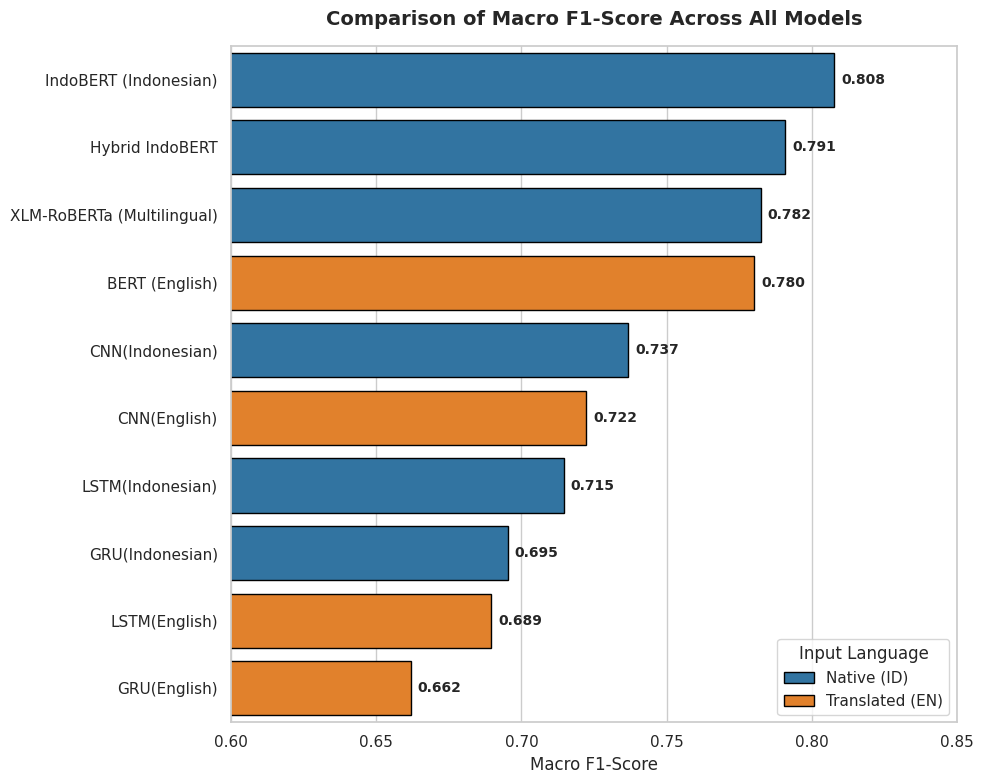

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

# y = Model Strategy (Category), x = Macro F1-Score (Value)
barplot = sns.barplot(
    data=df_final_report,
    y='Model Strategy', # Model name on Y axis (Left)
    x='Macro F1-Score', # Value on X axis (Bottom)
    hue='Input Language',
    palette={'Native (ID)': '#1f77b4', 'Translated (EN)': '#ff7f0e'},
    edgecolor='black',
    orient='h'
)

# Title and Label
plt.title('Comparison of Macro F1-Score Across All Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Macro F1-Score', fontsize=12)
plt.ylabel('')

# Adding the number to the SAMPLING of each bar (not above)
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.3f', padding=5, fontsize=10, fontweight='bold')

plt.xlim(0.6, 0.85)

# Set legend
plt.legend(title='Input Language', loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()

# Save
plt.savefig('f1_score_horizontal.png', dpi=300, bbox_inches='tight')
print("Horizontal chart saved successfully!")
plt.show()